In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Estructura básica de un dataset para YOLO

```
dataset/
│
├── train/
│   ├── images/
│   │   ├── img1.jpg
│   │   ├── img2.jpg
│   │
│   └── labels/
│       ├── img1.txt
│       ├── img2.txt
│
├── valid/
│   ├── images/
│   └── labels/
│
└── data.yaml
```

In [2]:
!pip install -q ultralytics


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
from ultralytics import YOLO   # libreria que contiene el modelo
  # Para subir archivos desde tu ordenador
from IPython.display import Image, display  # Para mostrar imágenes en pantalla
# Image → carga la imagen
# display → la enseña 

import os   # Para trabajar con archivos y rutas dentro del entorno

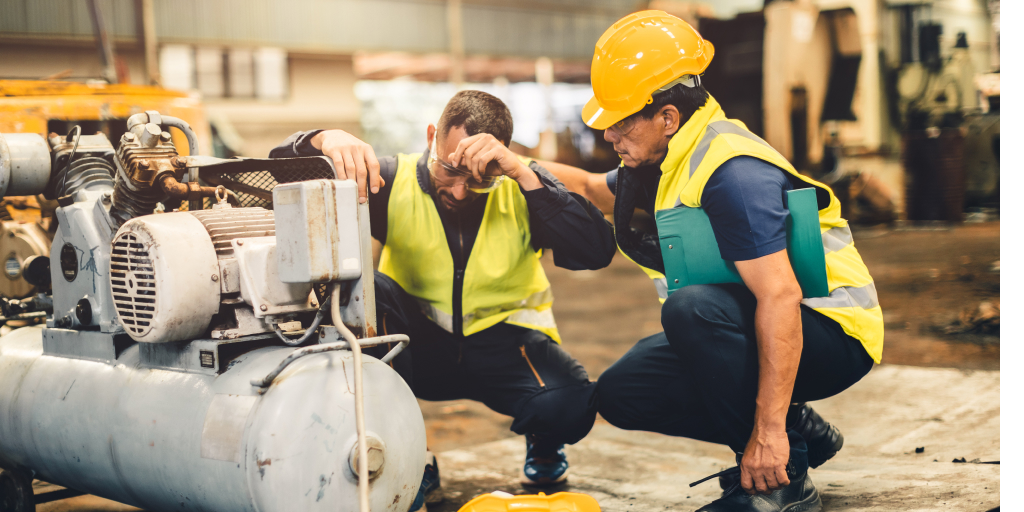

In [4]:
# Mostrar imagen

display(Image('img/IMAGEN_PRL.jpg'))

In [5]:
# Cargar modelo preentrenado

model = YOLO('yolov8n.pt')

In [6]:
# Hacer predicción

results = model('img/IMAGEN_PRL.jpg')


image 1/1 /Users/mag/github/yolo-fine-tuning/img/IMAGEN_PRL.jpg: 320x640 2 persons, 31.8ms
Speed: 1.5ms preprocess, 31.8ms inference, 0.6ms postprocess per image at shape (1, 3, 320, 640)


In [7]:
# YOLO devuelve SIEMPRE una lista de resultados
# Aunque solo pases una imagen
# results[0] → resultado de img1
# results[1] → resultado de img2

results[0].show()

In [8]:
# Importa la librería de YOLO (la versión moderna y sencilla)
# Carga un modelo preentrenado
# yolov8n = versión nano (rápida y ligera, ideal para empezar)

# data.yaml → define clases y rutas de imágenes
# epochs=10 → número de pasadas por los datos
# imgsz=320 → tamaño de imagen (más pequeño = más rápido, menos precisión)

# En resumen cargas un modelo ya entrenado y lo adaptas (fine_tuning) 
# con tu dataset


from ultralytics import YOLO

model = YOLO('yolov8n.pt')

model.train(
    data='dataset/data.yaml',
    epochs=10,
    imgsz=320
)

Ultralytics 8.4.36 🚀 Python-3.13.2 torch-2.11.0 CPU (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pre

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x125a4c500>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [9]:
# Epoch → número de pasada por los datos
# GPU_mem → memoria usada (informativo)

# box_loss → error en la localización de objetos (↓ mejor)
# cls_loss → error en la clasificación (↓ mejor)
# dfl_loss → ajuste fino de las cajas (↓ mejor)

# Instances → objetos detectados en el batch
# Images → número de imágenes
# Instances (abajo) → total de objetos en el dataset

# Box(P) → precisión (de lo que detecta, cuántos acierta) (↑ mejor)
# R → recall (de los reales, cuántos detecta) (↑ mejor)

# Regla: Loss ↓ y Precision/Recall ↑ = modelo mejora

In [18]:
# Elegimos el mejor modelo. El modelo de la mejor epoch

best_model = YOLO('runs/detect/train/best.pt')

FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect/train/best.pt'

In [16]:
# Predicción con nuestra imagen inicial

results = best_model('img/IMAGEN_PRL.jpg')

TypeError: model='runs/detect/train' is not a supported model format. Ultralytics supports: ('PyTorch', 'TorchScript', 'ONNX', 'OpenVINO', 'TensorRT', 'CoreML', 'TensorFlow SavedModel', 'TensorFlow GraphDef', 'TensorFlow Lite', 'TensorFlow Edge TPU', 'TensorFlow.js', 'PaddlePaddle', 'MNN', 'NCNN', 'IMX', 'RKNN', 'ExecuTorch', 'Axelera AI')
See https://docs.ultralytics.com/modes/predict for help.

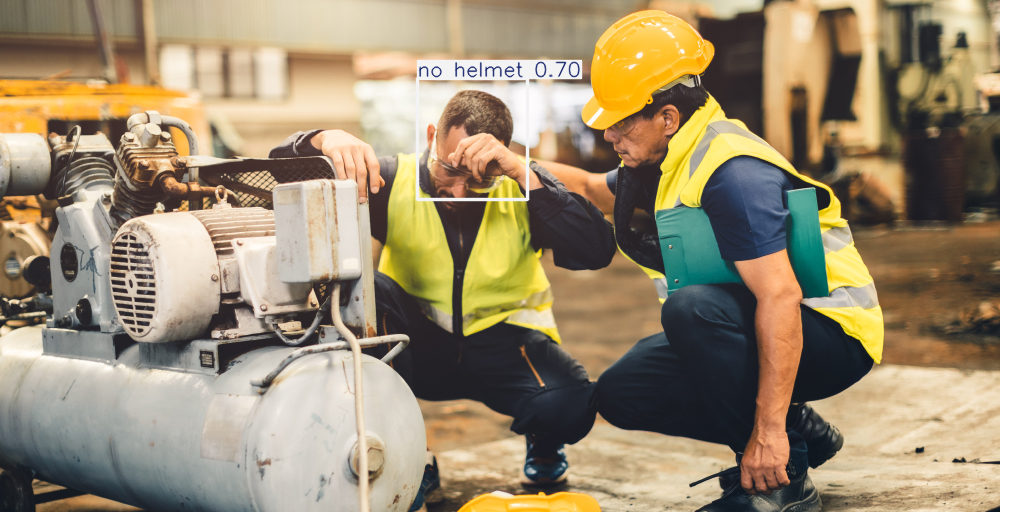

In [10]:
# Mostrar resultado

results[0].show()

---

# Fase 1: Clasificar una nueva imagen de riesgo laboral

In [ ]:
# We use the best model we have trained
best_model = YOLO('best.pt')
# Prediction with new image
results = best_model('img/sparks_test.jpg')
# Show final result
results[0].show()